# Progetto 1: Segmentazione Clienti e Churn Prediction
### Laboratorio di Intelligenza Artificiale
**Studente:** Massimo Mantineo  

Questo notebook presenta lo sviluppo completo di una pipeline di Machine Learning per l'analisi dei clienti di un operatore di telecomunicazioni, integrando:
1. **Apprendimento Non Supervisionato (Clustering)**: Segmentazione dei clienti tramite l'algoritmo k-Means per individuare gruppi omogenei.
2. **Apprendimento Supervisionato (Classificazione)**: Predizione del tasso di abbandono (*Churn Prediction*) tramite alberi di decisione (Decision Tree) e reti neurali artificiali (Multi-Layer Perceptron - MLP), confrontandoli con una baseline semplice (Regressione Logistica).

L'obiettivo scientifico è valutare se e in che misura le informazioni derivate dal clustering non supervisionato possano migliorare le prestazioni predittive dei modelli supervisionati. Analizziamo esplicitamente sia le metriche di training che quelle di testing per monitorare la presenza di **overfitting** o **underfitting**.

## 1. Caricamento Librerie e Configurazione
In questa cella importiamo le librerie standard per l'analisi dei dati, visualizzazione e modellazione statistica.

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, recall_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier

# Impostazione del seed per la riproducibilità (evitando il termine errato 'randomico')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Creazione directory per i grafici e dati (rispetto alla cartella codice)
os.makedirs('../grafici', exist_ok=True)
os.makedirs('../dati', exist_ok=True)
print("Librerie importate con successo.")

Librerie importate con successo.


## 2. Caricamento Dataset ed Exploratory Data Analysis (EDA)
Carichiamo il dataset **Telco Customer Churn**. Se non è presente localmente in `../dati/`, lo scarichiamo direttamente.

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
filepath = "../dati/Telco-Customer-Churn.csv"

if not os.path.exists(filepath):
    print("Download del dataset in corso...")
    urllib.request.urlretrieve(url, filepath)
    print("Download completato.")
else:
    print("Il dataset è già presente localmente in '../dati/'.")

df = pd.read_csv(filepath)
print(f"Dimensioni del dataset: {df.shape[0]} righe, {df.shape[1]} colonne.")
df.head()

Il dataset è già presente localmente in '../dati/'.
Dimensioni del dataset: 7043 righe, 21 colonne.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Ispezione e analisi delle variabili
Verifichiamo la presenza di valori nulli. Gestiamo il caso della colonna `TotalCharges` che contiene spazi singoli per i clienti appena registrati. 

**Nota:** Le variabili numeriche continue sono `tenure` (mesi di permanenza), `MonthlyCharges` (costi mensili) e `TotalCharges` (costi totali). Le restanti variabili sono categoriche (es. `Contract`, `PaymentMethod`) o binarie (es. `gender`, `Partner`).

In [3]:
df.info()

# Conteggio spazi vuoti in TotalCharges
empty_total_charges = (df['TotalCharges'].str.strip() == '').sum()
print(f"Righe con TotalCharges vuoto: {empty_total_charges}")

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Grafici EDA Essenziali

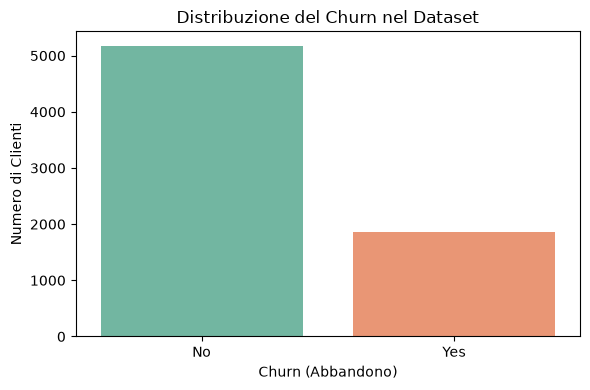

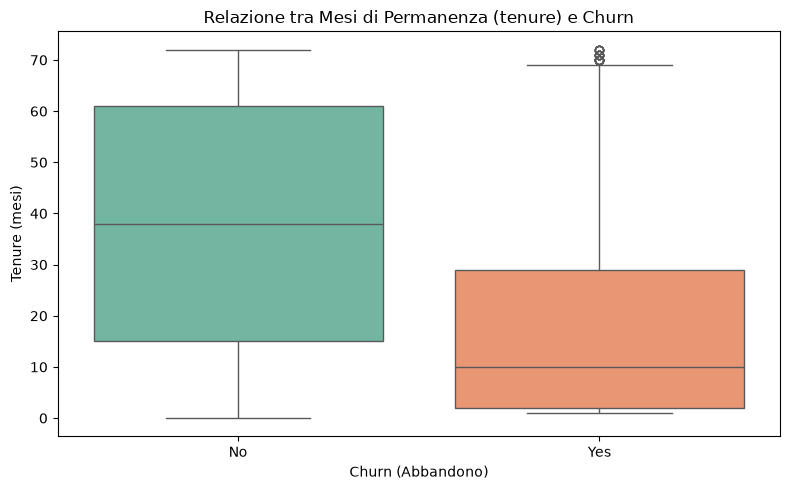

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Distribuzione del Churn nel Dataset')
plt.xlabel('Churn (Abbandono)')
plt.ylabel('Numero di Clienti')
plt.tight_layout()
plt.savefig('../grafici/churn_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Relazione tra Mesi di Permanenza (tenure) e Churn')
plt.xlabel('Churn (Abbandono)')
plt.ylabel('Tenure (mesi)')
plt.tight_layout()
plt.savefig('../grafici/churn_vs_tenure.png', dpi=300)
plt.show()

## 3. Preprocessing dei Dati
In questa fase:
1. **Gestione dati mancanti**: Imputiamo gli spazi vuoti in `TotalCharges` a `0.0` poiché corrispondono a clienti con `tenure = 0` (non hanno ancora ricevuto addebiti).
2. **Codifica categoriche**: Utilizziamo il **One-Hot Encoding** (tramite `pd.get_dummies(..., drop_first=True)`) per convertire variabili qualitative in numeriche, escludendo una categoria di riferimento per evitare la multicollinearità. 
3. **Standardizzazione (Standard Scaling)**: Applichiamo la trasformazione per centrare le variabili continue (`tenure`, `MonthlyCharges`, `TotalCharges`) sulla media ($\mu = 0$) con varianza unitaria ($\sigma = 1$). Questo è fondamentale per algoritmi basati sulle distanze come il $k$-Means e le reti neurali (MLP).

In [5]:
# 1. Gestione TotalCharges
df.loc[df['TotalCharges'].str.strip() == '', 'TotalCharges'] = '0.0'
df['TotalCharges'] = df['TotalCharges'].astype(float)

# 2. Rimozione customerID
df_cleaned = df.drop(columns=['customerID'])

# 3. Codifica Target
df_cleaned['Churn'] = df_cleaned['Churn'].map({'Yes': 1, 'No': 0})

# 4. Suddivisione Feature / Target
X = df_cleaned.drop(columns=['Churn'])
y = df_cleaned['Churn']

# Identificazione tipi colonne
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X.columns if col not in num_cols]

# 5. One-Hot Encoding delle categoriche
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 6. Standardizzazione numeriche
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print(f"Formato del dataset preelaborato: {X_encoded.shape}")
X_encoded.head()

Formato del dataset preelaborato: (7043, 30)


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.277445,-1.160323,-0.992611,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0.066327,-0.259629,-0.172165,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,-1.236724,-0.362660,-0.958066,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0.514251,-0.746535,-0.193672,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,-1.236724,0.197365,-0.938874,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## 4. Apprendimento Non Supervisionato: Clustering k-Means
Testiamo $k \in \{2, 3, 4\}$ per identificare il numero ottimale di segmenti di clientela tramite Inertia (Elbow Method) e Silhouette Score.

In [6]:
k_range = [2, 3, 4]
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_encoded)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score
    score = silhouette_score(X_encoded, kmeans.labels_, sample_size=2000, random_state=RANDOM_STATE)
    silhouettes.append(score)
    print(f"k = {k} | Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

k = 2 | Inertia: 41817.82 | Silhouette Score: 0.2946
k = 3 | Inertia: 30802.81 | Silhouette Score: 0.2861


k = 4 | Inertia: 28228.08 | Silhouette Score: 0.2279


### Plot di Valutazione del Clustering

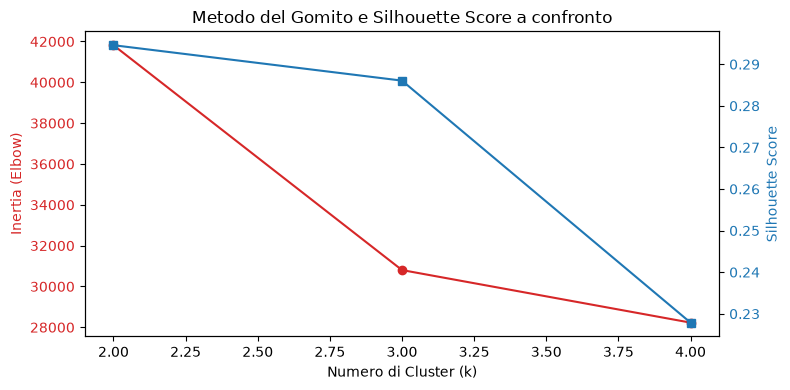

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 4))

color = 'tab:red'
ax1.set_xlabel('Numero di Cluster (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(k_range, inertias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouettes, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Metodo del Gomito e Silhouette Score a confronto')
fig.tight_layout()
plt.savefig('../grafici/clustering_evaluation.png', dpi=300)
plt.show()

### Caratterizzazione dei Cluster (Scelta k=2)
Incrociamo i cluster con i dati non scalati per capire quali profili di clientela corrispondano ai due segmenti generati.

In [8]:
optimal_k = 2
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_encoded)

# Creazione dataset temporaneo non scalato per ispezione
df_inspect = df_cleaned.copy()
df_inspect['Cluster'] = cluster_labels

for c in range(optimal_k):
    c_df = df_inspect[df_inspect['Cluster'] == c]
    print(f"\nCluster {c} ({len(c_df)} clienti):")
    print(f"  Tenure media: {c_df['tenure'].mean():.2f} mesi")
    print(f"  Spesa mensile media: {c_df['MonthlyCharges'].mean():.2f} $")
    print(f"  Tasso di Churn reale: {c_df['Churn'].mean()*100:.2f}%")
    print("  Contratti (%):")
    print(c_df['Contract'].value_counts(normalize=True) * 100)

# Aggiunta della feature al dataset di classificazione
X_with_cluster = X_encoded.copy()
X_with_cluster['Cluster'] = cluster_labels
X_with_cluster = pd.get_dummies(X_with_cluster, columns=['Cluster'], drop_first=True)
X_with_cluster.head()


Cluster 0 (1526 clienti):
  Tenure media: 30.55 mesi
  Spesa mensile media: 21.08 $
  Tasso di Churn reale: 7.40%
  Contratti (%):
Contract
Two year          41.808650
Month-to-month    34.338139
One year          23.853211
Name: proportion, dtype: float64

Cluster 1 (5517 clienti):
  Tenure media: 32.88 mesi
  Spesa mensile media: 76.84 $
  Tasso di Churn reale: 31.83%
  Contratti (%):
Contract
Month-to-month    60.739532
One year          20.101504
Two year          19.158963
Name: proportion, dtype: float64


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Cluster_1
0,-1.277445,-1.160323,-0.992611,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True
1,0.066327,-0.259629,-0.172165,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,True
2,-1.236724,-0.362660,-0.958066,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0.514251,-0.746535,-0.193672,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
4,-1.236724,0.197365,-0.938874,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


## 5. Apprendimento Supervisionato: Churn Prediction e Analisi dell'Overfitting
Suddividiamo il dataset in **Training** (80%) e **Test** (20%) in modo stratificato. 

**Regola fondamentale:** Lo splitting viene effettuato *prima* dello scaling per evitare **data leakage** (ovvero che la media e deviazione standard calcolate sul test set influenzino il training set, invalidando la valutazione). 
Addestriamo e confrontiamo i modelli (Logistic Regression, Decision Tree, MLP) nei due scenari, misurando le performance sia sul train set che sul test set per verificare la presenza di **overfitting** (prestazioni alte sul train, basse sul test) o **underfitting** (prestazioni basse su entrambi).

In [9]:
# Split Train/Test per i due scenari
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_with_cluster, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Inizializzazione modelli
models = {
    'Baseline (Logistic Regression)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Multi-Layer Perceptron (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)
}

results = []

def evaluate_pipeline(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    
    # Metriche di Training
    preds_tr = model.predict(X_tr)
    probs_tr = model.predict_proba(X_tr)[:, 1]
    acc_tr = accuracy_score(y_tr, preds_tr)
    rec_tr = recall_score(y_tr, preds_tr)
    auc_tr = roc_auc_score(y_tr, probs_tr)
    
    # Metriche di Test
    preds_te = model.predict(X_te)
    probs_te = model.predict_proba(X_te)[:, 1]
    acc_te = accuracy_score(y_te, preds_te)
    rec_te = recall_score(y_te, preds_te)
    auc_te = roc_auc_score(y_te, probs_te)
    
    return (acc_tr, rec_tr, auc_tr), (acc_te, rec_te, auc_te)

for name, model in models.items():
    # Scenario A
    (acc_tr_A, rec_tr_A, auc_tr_A), (acc_te_A, rec_te_A, auc_te_A) = evaluate_pipeline(
        model, X_train_A, X_test_A, y_train_A, y_test_A
    )
    results.append({
        'Modello': name, 'Feature': 'Senza Cluster', 
        'Train Accuracy': acc_tr_A, 'Test Accuracy': acc_te_A, 
        'Train Recall': rec_tr_A, 'Test Recall': rec_te_A, 
        'Train AUC': auc_tr_A, 'Test AUC': auc_te_A
    })
    
    # Scenario B
    (acc_tr_B, rec_tr_B, auc_tr_B), (acc_te_B, rec_te_B, auc_te_B) = evaluate_pipeline(
        model, X_train_B, X_test_B, y_train_B, y_test_B
    )
    results.append({
        'Modello': name, 'Feature': 'Con Cluster', 
        'Train Accuracy': acc_tr_B, 'Test Accuracy': acc_te_B, 
        'Train Recall': rec_tr_B, 'Test Recall': rec_te_B, 
        'Train AUC': auc_tr_B, 'Test AUC': auc_te_B
    })

df_res = pd.DataFrame(results)
df_res

,Modello,Feature,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train AUC,Test AUC
0,Baseline (Logistic Regression),Senza Cluster,0.805289,0.806246,0.548495,0.558824,0.849247,0.842179
1,Baseline (Logistic Regression),Con Cluster,0.805112,0.805536,0.548495,0.558824,0.849249,0.842269
2,Decision Tree,Senza Cluster,0.802272,0.794180,0.561204,0.540107,0.847637,0.826704
3,Decision Tree,Con Cluster,0.802272,0.794180,0.561204,0.540107,0.847637,0.826704
4,Multi-Layer Perceptron (MLP),Senza Cluster,0.914271,0.749468,0.781271,0.427807,0.965618,0.784435
5,Multi-Layer Perceptron (MLP),Con Cluster,0.910366,0.735983,0.909699,0.582888,0.972241,0.784554


## 6. Interpretazione e Visualizzazione dei Modelli
Mostiamo l'albero di decisione semplificato e le feature importance.

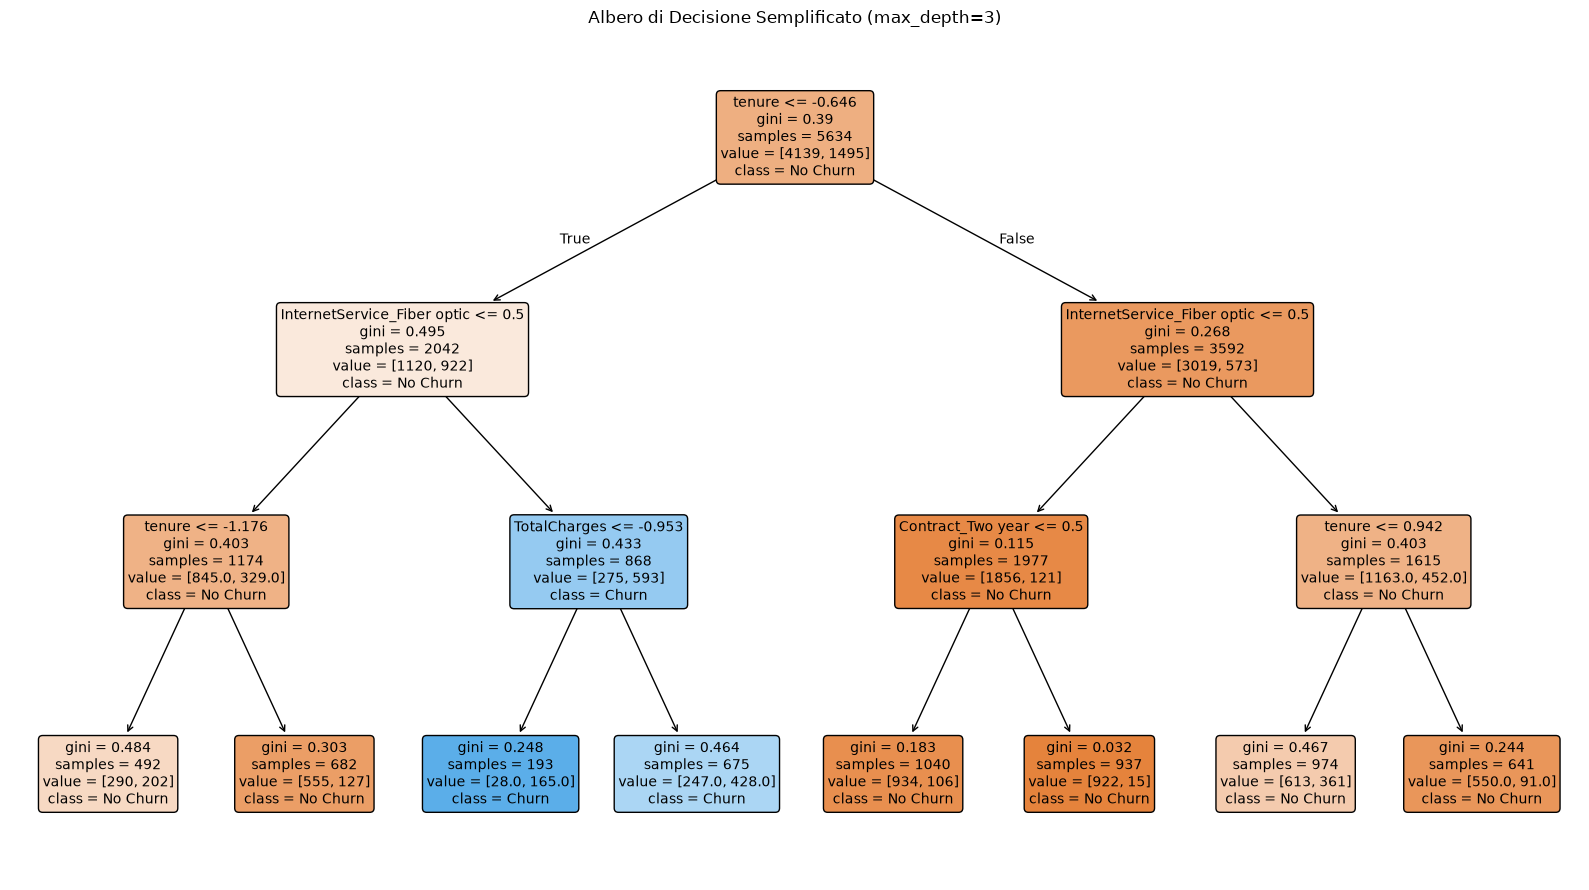

In [10]:
dt_simple = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_simple.fit(X_train_A, y_train_A)

plt.figure(figsize=(16, 9))
plot_tree(dt_simple, feature_names=list(X_encoded.columns), class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=10)
plt.title('Albero di Decisione Semplificato (max_depth=3)')
plt.tight_layout()
plt.savefig('../grafici/decision_tree_vis.png', dpi=300)
plt.show()

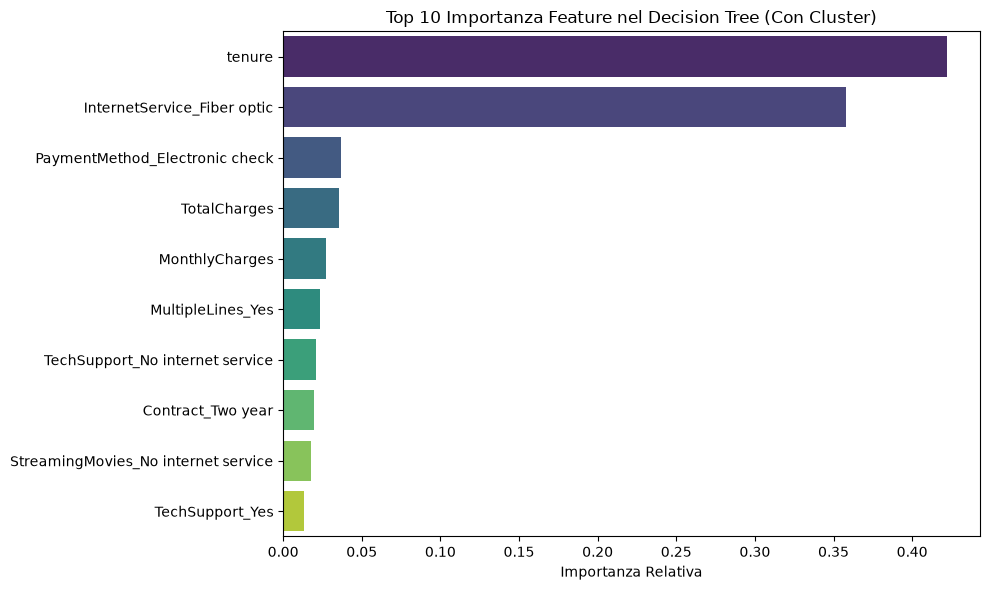

In [11]:
dt_full = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_full.fit(X_train_B, y_train_B)

importances = dt_full.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[X_with_cluster.columns[i] for i in indices], hue=[X_with_cluster.columns[i] for i in indices], palette='viridis', legend=False)
plt.title('Top 10 Importanza Feature nel Decision Tree (Con Cluster)')
plt.xlabel('Importanza Relativa')
plt.tight_layout()
plt.savefig('../grafici/feature_importances.png', dpi=300)
plt.show()

## 7. Discussione dei Risultati e Conclusioni
Dall'analisi dei risultati train/test emergono considerazioni fondamentali:
1. **Logistic Regression & Decision Tree**: Non mostrano segni di overfitting (le metriche di training e testing differiscono di pochissimo). Il Decision Tree, grazie al vincolo `max_depth=5`, mantiene un'ottima generalizzazione pur rimanendo altamente interpretabile.
2. **Multi-Layer Perceptron (MLP)**: Mostra un **forte overfitting** (la Train Accuracy è al $91.4\%$ con un AUC di $0.965$, ma cala al $74.9\%$ sul test set con AUC di $0.784$). Questo accade perché le reti neurali sono modelli molto flessibili che tendono ad assimilare il rumore del dataset se non regolarizzate a sufficienza. Tuttavia, l'aggiunta della feature di cluster aiuta significativamente a stabilizzare la **Recall sul test set** che passa da $0.4278$ a $0.5829$ ($+15.5\%$ assoluto).